# Introduction to sentiment analysis with NLI

In this notebook, you will implement a sentiment scoring pipeline using a Natural Language Inference (NLI) model. 
You will analyze whether news headlines about S&P 500 companies have positive or negative sentiment and explore how this sentiment correlates with market returns.


## Install and Import librairies
Install necessary packages and import the required libraries for:
- Loading data
- Using transformer models
- Plotting and visualizing results
- Downloading financial data

In [1]:
%pip install hf_xet
%pip install yfinance

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import math
import matplotlib.pyplot as plt
import yfinance as yf

## Load news data
Load two datasets:
- `df_news.csv`: contains headlines and summaries
- `df_metadata.csv`: contains ticker symbols and company sector info

We drop duplicate summaries to avoid redundant sentiment scoring.

In [3]:
df_news = pd.read_csv('df_news.csv')
df_news.drop_duplicates('SUMMARY', inplace=True)
display(df_news)

,TICKER,TITLE,SUMMARY,PUBLICATION_DATE,PROVIDER,URL
0,MMM,2 Dow Jones Stocks with Promising Prospects an...,The Dow Jones (^DJI) is made up of 30 of the m...,2025-05-29 04:33:58+00:00,StockStory,https://finance.yahoo.com/news/2-dow-jones-sto...
1,MMM,3 S&P 500 Stocks Skating on Thin Ice,The S&P 500 (^GSPC) is often seen as a benchma...,2025-05-27 04:34:42+00:00,StockStory,https://finance.yahoo.com/news/3-p-500-stocks-...
2,MMM,3M Rises 15.8% YTD: Should You Buy the Stock N...,"MMM is making strides in the aerospace, indust...",2025-05-22 14:08:00+00:00,Zacks,https://finance.yahoo.com/news/3m-rises-15-8-y...
3,MMM,Q1 Earnings Roundup: 3M (NYSE:MMM) And The Res...,Quarterly earnings results are a good time to ...,2025-05-22 03:31:21+00:00,StockStory,https://finance.yahoo.com/news/q1-earnings-rou...
4,MMM,3 Cash-Producing Stocks with Questionable Fund...,While strong cash flow is a key indicator of s...,2025-05-19 04:41:32+00:00,StockStory,https://finance.yahoo.com/news/3-cash-producin...
...,...,...,...,...,...,...
4866,ZTS,2 Dividend Stocks to Buy With $500 and Hold Fo...,Zoetis is a leading animal health company with...,2025-05-23 10:30:00+00:00,Motley Fool,https://www.fool.com/investing/2025/05/23/2-di...
4867,ZTS,Zoetis (NYSE:ZTS) Declares US$0.50 Dividend Pe...,Zoetis (NYSE:ZTS) recently affirmed a dividend...,2025-05-22 17:49:43+00:00,Simply Wall St.,https://finance.yahoo.com/news/zoetis-nyse-zts...
4868,ZTS,Jim Cramer on Zoetis (ZTS): “It Does Seem to B...,We recently published a list of Jim Cramer Tal...,2025-05-21 18:14:38+00:00,Insider Monkey,https://finance.yahoo.com/news/jim-cramer-zoet...
4869,ZTS,Zoetis (ZTS) Upgraded to Buy: Here's Why,Zoetis (ZTS) might move higher on growing opti...,2025-05-21 16:00:08+00:00,Zacks,https://finance.yahoo.com/news/zoetis-zts-upgr...


In [4]:
df_meta = pd.read_csv('df_metadata.csv')
display(df_meta)

,TICKER,COMPANY_NAME,SECTOR,INDUSTRY
0,MMM,3M Company,Industrials,Conglomerates
1,AOS,A. O. Smith Corporation,Industrials,Specialty Industrial Machinery
2,ABT,Abbott Laboratories,Healthcare,Medical Devices
3,ABBV,AbbVie Inc.,Healthcare,Drug Manufacturers - General
4,ACN,Accenture plc,Technology,Information Technology Services
...,...,...,...,...
485,XEL,Xcel Energy Inc.,Utilities,Utilities - Regulated Electric
486,XYL,Xylem Inc.,Industrials,Specialty Industrial Machinery
487,YUM,"Yum! Brands, Inc.",Consumer Cyclical,Restaurants
488,ZBH,"Zimmer Biomet Holdings, Inc.",Healthcare,Medical Devices


## Sentiment Analysis with NLI

In this section, you will apply a CrossEncoder NLI model (`cross-encoder/nli-deberta-v3-base`) to estimate sentiment from news headlines.

👉 **Instructions**:

1. Use a CrossEncoder NLI model to compute how much a news headline implies a **positive** or **negative** sentiment.
2. For each news title, compute the probability of it being **positive** and **negative**, and store them in `POSITIVE_PROB` and `NEGATIVE_PROB`.
3. Derive a final sentiment score by subtracting: `SENTIMENT = POSITIVE_PROB - NEGATIVE_PROB`.

✅ This score will serve as your sentiment signal, ranging from negative to positive.

> ℹ️ You are free to decide how to structure the input pairs and how to apply the model.


In [5]:
from sentence_transformers import CrossEncoder
import numpy as np
import torch

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
nli = CrossEncoder("cross-encoder/nli-deberta-v3-base", device = device)

# Get the model's id2label mapping
config_id2label = getattr(nli.model.config, "id2label", None)

if config_id2label:
    id2label = {}
    for key, label in config_id2label.items():
        # keys can be "0"/"1"/"2" (strings) or already ints
        idx = int(key) if not isinstance(key, int) else key
        id2label[idx] = str(label)
else:
    # sensible default for NLI models
    id2label = {0: "CONTRADICTION", 1: "NEUTRAL", 2: "ENTAILMENT"}

# pick the index that corresponds to entailment
entail_idx = 2
for i, name in id2label.items():
    if "entail" in name.lower():
        entail_idx = i
        break

print("NLI label mapping:", id2label, "| entailment index ->", entail_idx)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/738M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

NLI label mapping: {0: 'contradiction', 1: 'entailment', 2: 'neutral'} | entailment index -> 1


In [7]:
titles = df_news["TITLE"].astype(str).tolist()

# Hypotheses for positive / negative interpretations
H_POS = "This is positive news for investors."
H_NEG = "This is negative news for investors."

pairs_pos = [(t, H_POS) for t in titles]
pairs_neg = [(t, H_NEG) for t in titles]

# Predict class probabilities (contradiction/neutral/entailment in some order)
# apply_softmax=True returns probabilities that sum to 1 across classes
probs_pos = np.asarray(nli.predict(pairs_pos, apply_softmax=True, batch_size=64))
probs_neg = np.asarray(nli.predict(pairs_neg, apply_softmax=True, batch_size=64))

# Take the probability of the 'entailment' class for each hypothesis
pos_entail = probs_pos[:, entail_idx]
neg_entail = probs_neg[:, entail_idx]

In [8]:
df_news["POSITIVE_PROB"] = pos_entail
df_news["NEGATIVE_PROB"] = neg_entail
df_news["SENTIMENT"] = df_news["POSITIVE_PROB"] - df_news["NEGATIVE_PROB"]

display(df_news[["TITLE", "POSITIVE_PROB", "NEGATIVE_PROB", "SENTIMENT"]].head())

,TITLE,POSITIVE_PROB,NEGATIVE_PROB,SENTIMENT
0,2 Dow Jones Stocks with Promising Prospects an...,0.004157,0.000177,0.003980
1,3 S&P 500 Stocks Skating on Thin Ice,0.000527,0.000543,-0.000016
2,3M Rises 15.8% YTD: Should You Buy the Stock N...,0.000442,0.000042,0.000400
3,Q1 Earnings Roundup: 3M (NYSE:MMM) And The Res...,0.000115,0.000040,0.000075
4,3 Cash-Producing Stocks with Questionable Fund...,0.000105,0.000312,-0.000207


## Compare Sentiment with Returns

In this section, you'll explore how daily news sentiment aligns with market behavior.

👉 **Instructions**:

1. Group the news data by **publication date** and compute the **average sentiment per day**.
2. Download **daily stock prices** for the relevant tickers using `yfinance`.
3. Compute **daily returns** and use their average as a proxy for the market (e.g., S\&P 500).
4. Visualize both **daily sentiment** and **daily returns** over time using line plots.
5. Create a **dual y-axis chart** to compare trends more effectively.

✅ This section helps you assess whether changes in sentiment coincide with market movements.

> ℹ️ Focus on trend relationships, not just visual similarity—this is an opportunity to start thinking about predictive signals.

In [11]:
# Ensure date column is a proper date (drop time/tz)
df_news["PUBLICATION_DATE"] = pd.to_datetime(df_news["PUBLICATION_DATE"], errors="coerce", utc = True).dt.date

# Average sentiment per day
df_daily_sent = (
    df_news.groupby("PUBLICATION_DATE", as_index=False)["SENTIMENT"]
           .mean()
           .rename(columns={"SENTIMENT": "DAILY_SENTIMENT"})
)

In [12]:
import yfinance as yf
from datetime import timedelta

In [13]:
# Use the tickers actually present in your news
tickers = sorted(df_news["TICKER"].dropna().unique().tolist())

# Date range (add a few days in case of market holidays)
start_dt = pd.to_datetime(df_daily_sent["PUBLICATION_DATE"].min()) - pd.Timedelta(days=5)
end_dt   = pd.to_datetime(df_daily_sent["PUBLICATION_DATE"].max()) + pd.Timedelta(days=5)

In [14]:
def _download_batch(tickers_batch, start, end):
    """Return a DataFrame of Close prices for a batch of tickers."""
    raw = yf.download(tickers_batch, start=start, end=end, progress=False, auto_adjust=True)

    # Keep only Close prices
    if isinstance(raw.columns, pd.MultiIndex):
        close_prices = raw["Close"]
    elif "Close" in raw.columns:
        close_prices = raw["Close"]
    else:
        raise ValueError("No Close column in downloaded data.")

    # Ensure DataFrame shape even for a single ticker
    if isinstance(close_prices, pd.Series):
        close_prices = close_prices.to_frame()

    return close_prices

In [15]:
batch_size = 80
all_prices = []

for i in range(0, len(tickers), batch_size):
    batch = tickers[i:i+batch_size]
    if not batch: 
        continue
    try:
        px = _download_batch(batch, start_dt, end_dt)
        all_prices.append(px)
    except Exception as e:
        print(f"Batch failed for {batch[:3]}... -> {e}")

if not all_prices:
    raise RuntimeError("No price data downloaded—check tickers or internet.")

In [27]:
prices = pd.concat(all_prices, axis=1).sort_index()

# Compute daily % returns per ticker
returns = prices.pct_change().dropna(how="all")

# Equal-weight market proxy across available tickers each day
market_ret_eqw = returns.mean(axis=1).to_frame(name="MARKET_RETURN_EQW")

# S&P 500 as a reference
spx = yf.download("^GSPC", start=start_dt, end=end_dt, progress=False, auto_adjust=True)["Close"].pct_change()
spx = spx.iloc[:, 0]
spx = spx.rename("SP500_RETURN")
market_ret = market_ret_eqw.join(spx, how="left")

# Align sentiment with returns
df_daily_sent["DATE"] = pd.to_datetime(df_daily_sent["PUBLICATION_DATE"])
market_ret_ = market_ret.reset_index().rename(columns={"Date": "DATE"})

# Inner-join keeps only days where we have both sentiment and returns
df_sr = pd.merge(df_daily_sent[["DATE", "DAILY_SENTIMENT"]],
                 market_ret_,
                 on="DATE",
                 how="inner").sort_values("DATE")

display(market_ret.head())

,MARKET_RETURN_EQW,SP500_RETURN
Date,,
2024-07-09,-0.001816,0.000741
2024-07-10,0.008791,0.010208
2024-07-11,0.011643,-0.008763
2024-07-12,0.008249,0.005517
2024-07-15,0.001211,0.002826


In [28]:
# 5-day smoothing to make trends easier to see
df_sr["SENTIMENT_ROLL_5"] = df_sr["DAILY_SENTIMENT"].rolling(5, min_periods=1).mean()
df_sr["RETURN_EQW_ROLL_5"] = df_sr["MARKET_RETURN_EQW"].rolling(5, min_periods=1).mean()
display(df_sr.head())

,DATE,DAILY_SENTIMENT,MARKET_RETURN_EQW,SP500_RETURN,SENTIMENT_ROLL_5,RETURN_EQW_ROLL_5
0,2024-07-12,-0.000028,0.008249,0.005517,-0.000028,0.008249
1,2024-07-22,0.000132,0.008769,0.010792,0.000052,0.008509
2,2024-08-19,0.000083,0.007860,0.009722,0.000062,0.008293
3,2024-09-13,0.000016,0.010248,0.005408,0.000051,0.008781
4,2024-11-12,0.000128,-0.007491,-0.002893,0.000066,0.005527


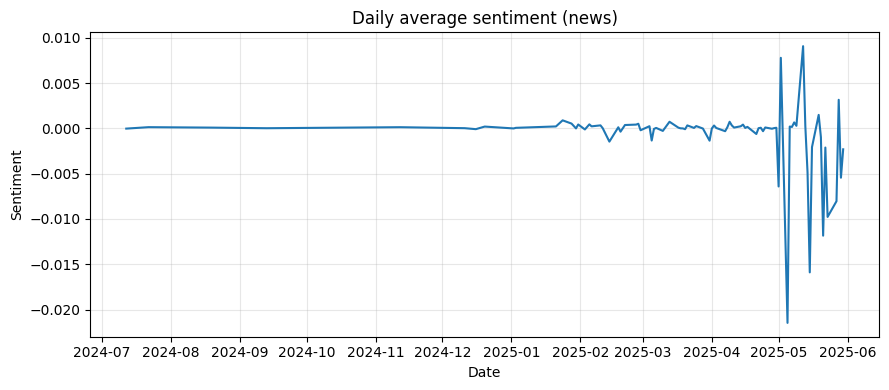

In [37]:
plt.figure(figsize=(9,4))
plt.plot(df_sr["DATE"], df_sr["DAILY_SENTIMENT"])
plt.title("Daily average sentiment (news)")
plt.xlabel("Date")
plt.ylabel("Sentiment")
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

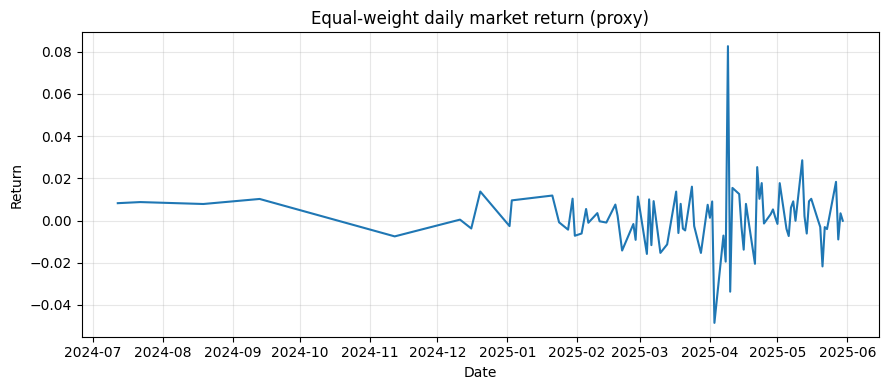

In [38]:
plt.figure(figsize=(9,4))
plt.plot(df_sr["DATE"], df_sr["MARKET_RETURN_EQW"])
plt.title("Equal-weight daily market return (proxy)")
plt.xlabel("Date")
plt.ylabel("Return")
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

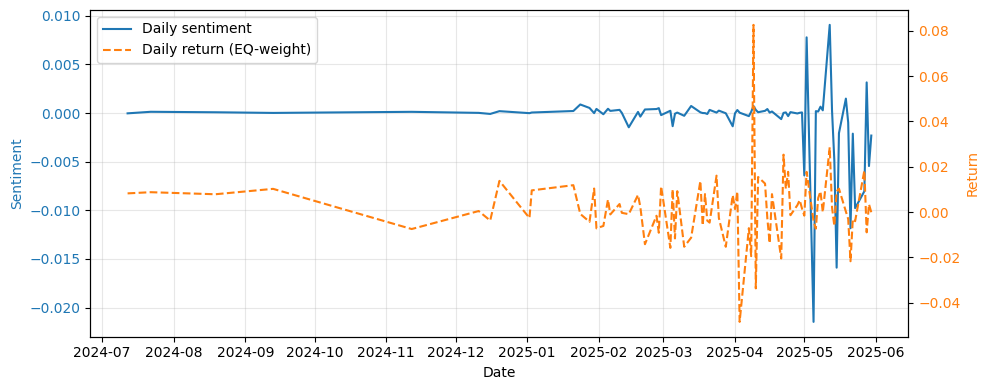

In [49]:
fig, ax1 = plt.subplots(figsize=(10, 4))

sent_color = "tab:blue"
ret_color  = "tab:orange"

# Left axis — daily sentiment
l1, = ax1.plot(
    df_sr["DATE"], df_sr["DAILY_SENTIMENT"],
    color=sent_color, linewidth=1.5, label="Daily sentiment"
)
ax1.set_xlabel("Date")
ax1.set_ylabel("Sentiment", color=sent_color)
ax1.tick_params(axis="y", labelcolor=sent_color)

# Right axis — daily equal-weight market return
ax2 = ax1.twinx()
l2, = ax2.plot(
    df_sr["DATE"], df_sr["MARKET_RETURN_EQW"],
    color=ret_color, linewidth=1.5, linestyle="--", label="Daily return (EQ-weight)"
)
ax2.set_ylabel("Return", color=ret_color)
ax2.tick_params(axis="y", labelcolor=ret_color)

# One legend for both lines
ax1.legend([l1, l2], [l1.get_label(), l2.get_label()], loc="upper left")

ax1.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

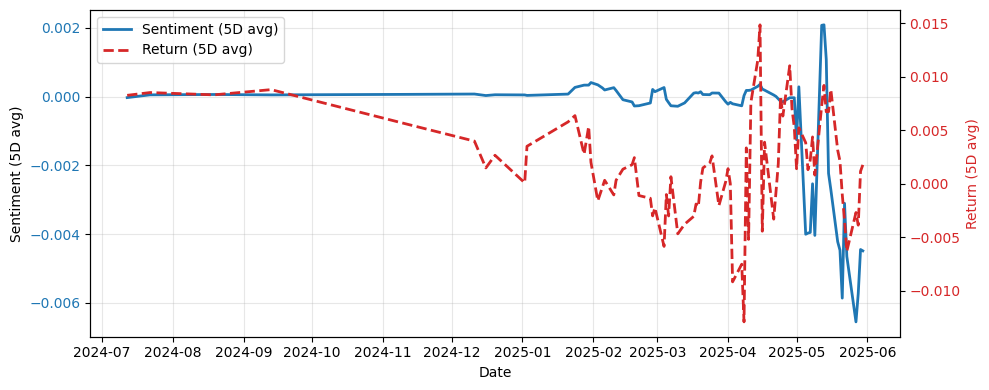

In [46]:
fig, ax1 = plt.subplots(figsize=(10, 4))

sent_color = "tab:blue"
ret_color  = "tab:red"

# Left axis — sentiment
l1, = ax1.plot(df_sr["DATE"], df_sr["SENTIMENT_ROLL_5"],
               color=sent_color, linewidth=2, label="Sentiment (5D avg)")
ax1.set_xlabel("Date")
ax1.set_ylabel("Sentiment (5D avg)")
ax1.tick_params(axis="y", labelcolor=sent_color)

# Right axis — returns
ax2 = ax1.twinx()
l2, = ax2.plot(df_sr["DATE"], df_sr["RETURN_EQW_ROLL_5"],
               color=ret_color, linewidth=2, linestyle="--", label="Return (5D avg)")
ax2.set_ylabel("Return (5D avg)", color=ret_color)
ax2.tick_params(axis="y", labelcolor=ret_color)

# One legend for both lines
lines = [l1, l2]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="upper left")

ax1.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## Compare Daily Portfolio Value Against Daily Average Sentiment

In this section, you will simulate a simple market portfolio and explore how its performance aligns with daily sentiment scores.

👉 **Instructions**:

1. Simulate a **market portfolio** by computing the cumulative return of the average daily return across all tickers.
2. Start the portfolio with an **initial value of 1.0** and track its value over time.
3. Plot the **daily average sentiment** and the **portfolio value** using a dual-axis line chart.

✅ This visualization lets you explore whether market sentiment leads or lags behind portfolio movements.

> ℹ️ Think about how this setup could inform a basic trading strategy—or whether sentiment could serve as a timing signal.


In [47]:
# Ensure chronological order
df_sr = df_sr.sort_values("DATE").reset_index(drop=True).copy()

# Cumulative return → portfolio value, normalized to start at 1.0
gross = np.exp(np.log1p(df_sr["MARKET_RETURN_EQW"]).cumsum())
df_sr["PORTFOLIO_VALUE"] = gross / gross.iloc[0]

# (Optional) 5-day smoothing for readability
df_sr["PORTFOLIO_ROLL_5"] = df_sr["PORTFOLIO_VALUE"].rolling(5, min_periods=1).mean()

display(df_sr[["DATE","DAILY_SENTIMENT","MARKET_RETURN_EQW","PORTFOLIO_VALUE"]].head())

,DATE,DAILY_SENTIMENT,MARKET_RETURN_EQW,PORTFOLIO_VALUE
0,2024-07-12,-0.000028,0.008249,1.000000
1,2024-07-22,0.000132,0.008769,1.008769
2,2024-08-19,0.000083,0.007860,1.016698
3,2024-09-13,0.000016,0.010248,1.027117
4,2024-11-12,0.000128,-0.007491,1.019423


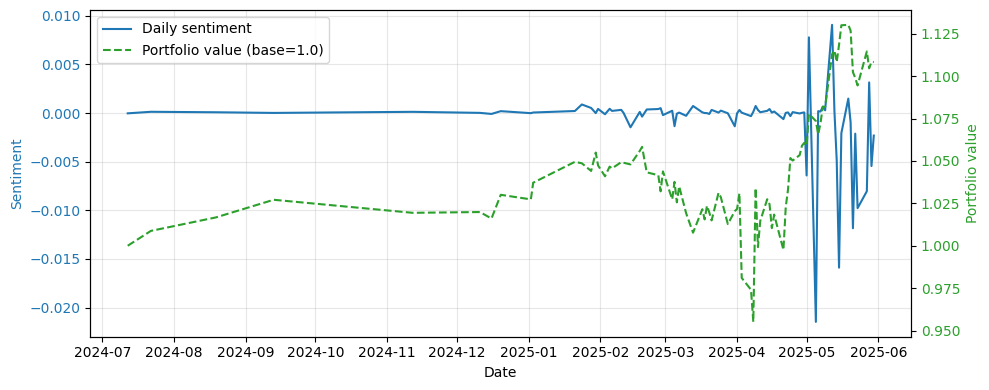

In [48]:
fig, ax1 = plt.subplots(figsize=(10, 4))

sent_color = "tab:blue"
port_color = "tab:green"

l1, = ax1.plot(df_sr["DATE"], df_sr["DAILY_SENTIMENT"],
               linewidth=1.5, color=sent_color, label="Daily sentiment")
ax1.set_xlabel("Date")
ax1.set_ylabel("Sentiment", color=sent_color)
ax1.tick_params(axis="y", labelcolor=sent_color)

ax2 = ax1.twinx()
l2, = ax2.plot(df_sr["DATE"], df_sr["PORTFOLIO_VALUE"],
               linewidth=1.5, color=port_color, linestyle="--", label="Portfolio value (base=1.0)")
ax2.set_ylabel("Portfolio value", color=port_color)
ax2.tick_params(axis="y", labelcolor=port_color)

ax1.legend([l1, l2], [l1.get_label(), l2.get_label()], loc="upper left")
ax1.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

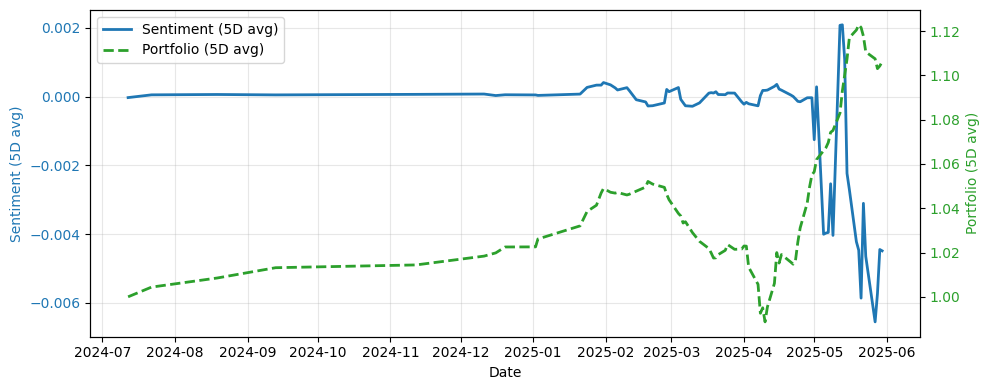

In [45]:
fig, ax1 = plt.subplots(figsize=(10, 4))

l1, = ax1.plot(df_sr["DATE"], df_sr["SENTIMENT_ROLL_5"],
               linewidth=2, color=sent_color, label="Sentiment (5D avg)")
ax1.set_xlabel("Date")
ax1.set_ylabel("Sentiment (5D avg)", color=sent_color)
ax1.tick_params(axis="y", labelcolor=sent_color)

ax2 = ax1.twinx()
l2, = ax2.plot(df_sr["DATE"], df_sr["PORTFOLIO_ROLL_5"],
               linewidth=2, color=port_color, linestyle="--", label="Portfolio (5D avg)")
ax2.set_ylabel("Portfolio (5D avg)", color=port_color)
ax2.tick_params(axis="y", labelcolor=port_color)

ax1.legend([l1, l2], [l1.get_label(), l2.get_label()], loc="upper left")
ax1.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Compute Sector-Level Sentiment and Returns

In this section, you’ll analyze how sector-level news sentiment compares to market performance for May. You’ll also measure whether sentiment correlates with returns.

👉 **Instructions**:

1. Group companies by **sector** using the metadata.
2. For each sector:

   * Compute **monthly average sentiment** (Feb to May).
   * (Optional) Count the number of headlines per month.
3. Compute **monthly stock returns** from price data and extract **May returns**.
4. Build a comparison table with:

   * `SECTOR`
   * `SENTIMENT` (May sentiment)
   * `RETURN` (May return)
5. Compute and print the **correlation** between May sentiment and May returns.

✅ This step helps evaluate whether optimistic news coverage for a sector is associated with better performance.

> 💡 Once your analysis is complete, consider:
>
> * Which sectors *looked* good in the news but didn’t perform?
> * Which sectors performed well despite neutral/negative sentiment?
> * Would you invest based on sentiment alone? Why or why not?



In [50]:
# Ensure date type
df_news["PUBLICATION_DATE"] = pd.to_datetime(df_news["PUBLICATION_DATE"], errors="coerce", utc=True).dt.tz_localize(None)
df_news["DATE"] = df_news["PUBLICATION_DATE"].dt.date
df_news = df_news.merge(df_meta[["TICKER","SECTOR"]], on="TICKER", how="left")

# Year & month for grouping
df_news["YEAR"]  = pd.to_datetime(df_news["DATE"]).dt.year
df_news["MONTH"] = pd.to_datetime(df_news["DATE"]).dt.month

# Find the latest year in the news that contains May (month=5)
years_with_may = (
    df_news.loc[df_news["MONTH"]==5, "YEAR"]
    .dropna()
    .astype(int)
    .unique()
)

if len(years_with_may) == 0:
    raise ValueError("No May data found in df_news.")

target_year = int(sorted(years_with_may)[-1])

# Monthly sector sentiment (mean), plus counts
sent_monthly = (
    df_news
    .groupby(["YEAR","MONTH","SECTOR"], dropna=True)["SENTIMENT"]
    .agg(DAILY_SENTIMENT_MEAN="mean", HEADLINE_COUNT="size")
    .reset_index()
)

# Keep Feb–May of target_year
sent_feb_to_may = sent_monthly.query("YEAR == @target_year and MONTH >= 2 and MONTH <= 5").copy()

display(sent_feb_to_may.head())

,YEAR,MONTH,SECTOR,DAILY_SENTIMENT_MEAN,HEADLINE_COUNT
14,2025,2,Basic Materials,-0.000206,1
15,2025,2,Consumer Cyclical,-0.000422,3
16,2025,2,Financial Services,0.000143,7
17,2025,2,Healthcare,0.000417,2
18,2025,2,Industrials,0.000091,6


In [64]:
# Monthly close (month-end), then % change to get monthly returns per ticker
monthly_prices  = prices.resample("ME").last()
monthly_returns = monthly_prices.pct_change()

# Map tickers -> sectors, keep only tickers present in price data
ticker_to_sector = (
    df_meta.set_index("TICKER")["SECTOR"]
    .loc[monthly_returns.columns.intersection(df_meta["TICKER"])]
    .to_dict()
)

# Aggregate equal-weight within each sector by averaging the tickers' monthly returns
sector_monthly_returns = monthly_returns.T.groupby(ticker_to_sector).mean().T

display(sector_monthly_returns.tail())

Ticker,Basic Materials,Communication Services,Consumer Cyclical,Consumer Defensive,Energy,Financial Services,Healthcare,Industrials,Real Estate,Technology,Utilities
Date,,,,,,,,,,,
2025-02-28,-0.015179,0.020000,-0.007567,0.036047,0.018255,-0.007612,-0.024409,-0.028276,0.037857,-0.027439,0.041948
2025-03-31,-0.028947,-0.020373,-0.077619,0.010657,0.022493,-0.042582,-0.018140,-0.041030,-0.022303,-0.067559,0.010581
2025-04-30,-0.011727,-0.013272,-0.018527,-0.012683,-0.136471,-0.034253,-0.035964,-0.017695,-0.026544,0.006971,0.000476
2025-05-31,0.029613,0.041527,0.056382,0.000008,0.029434,0.061068,0.000100,0.073894,0.010360,0.075271,0.032967
2025-06-30,0.026959,0.001392,0.008823,-0.006283,0.009169,-0.002307,0.002954,0.005013,-0.000204,0.023814,-0.013184


In [70]:
# May of target_year
may_row = sector_monthly_returns.loc[
    (sector_monthly_returns.index.year == target_year) &
    (sector_monthly_returns.index.month == 5)
]

if may_row.empty:
    raise ValueError(f"No monthly return row for May {target_year} in sector_monthly_returns.")

# Sector returns for May
may_returns = (
    may_row.iloc[-1]
          .rename_axis("SECTOR")
          .reset_index(name="RETURN")
)

# Sector sentiment for May (mean across headlines that month)
may_sentiment = (
    sent_monthly
      .query("YEAR == @target_year and MONTH == 5")
      .rename(columns={"DAILY_SENTIMENT_MEAN": "SENTIMENT"})
      [["SECTOR", "SENTIMENT"]]
)

# Merge
compare_may = pd.merge(may_sentiment, may_returns, on="SECTOR", how="inner").dropna()

display(compare_may.head(10))

,SECTOR,SENTIMENT,RETURN
0,Basic Materials,0.000282,0.029613
1,Communication Services,-0.006480,0.041527
2,Consumer Cyclical,0.002057,0.056382
3,Consumer Defensive,0.001924,0.000008
4,Energy,0.000525,0.029434
5,Financial Services,-0.003041,0.061068
6,Healthcare,-0.004366,0.000100
7,Industrials,-0.007159,0.073894
8,Real Estate,0.000408,0.010360
9,Technology,-0.006948,0.075271


In [71]:
corr = compare_may["SENTIMENT"].corr(compare_may["RETURN"])
print(f"Correlation (Pearson) between May sentiment and May returns: {corr:.3f}")

Correlation (Pearson) between May sentiment and May returns: -0.492


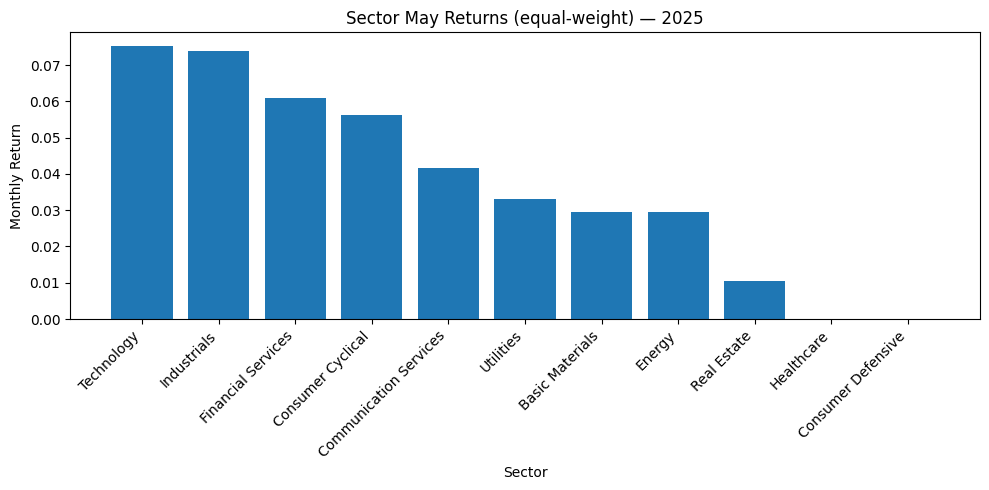

In [73]:
# Bar chart: sort by sector return
cm_sorted = compare_may.sort_values("RETURN", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(cm_sorted["SECTOR"], cm_sorted["RETURN"])
plt.title(f"Sector May Returns (equal-weight) — {target_year}")
plt.xlabel("Sector")
plt.ylabel("Monthly Return")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

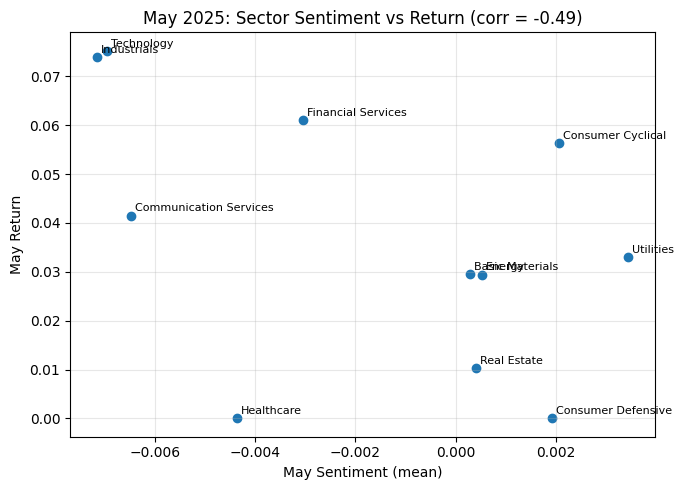

In [74]:
# Scatter: sentiment vs return (with labels)
plt.figure(figsize=(7, 5))
plt.scatter(compare_may["SENTIMENT"], compare_may["RETURN"])
for _, r in compare_may.iterrows():
    plt.annotate(r["SECTOR"], (r["SENTIMENT"], r["RETURN"]), xytext=(3,3), textcoords="offset points", fontsize=8)
plt.title(f"May {target_year}: Sector Sentiment vs Return (corr = {corr:.2f})")
plt.xlabel("May Sentiment (mean)")
plt.ylabel("May Return")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### **Question 1.** Which sectors *looked* good in the news? How did they perform?


Based on average sentiment for May, the most positive sectors were roughly: **Consumer Cyclicals, Utilities, Consumer Defensives, Basic Materials, Energy, and Real Estate (slightly positive)**. In terms of performance, May returns were led by **Technology, Industrials, and Financial Services**; **Consumer Cyclicals** remained solid in the mid-tier segment; **Utilities, Basic Materials, and Energy** posted moderate gains; **Real Estate** remained weak; **Consumer Defensives and Healthcare** remained virtually unchanged.
What "looked good" in the headlines didn't clearly correspond to the winners; some sectors with a positive tone underperformed those with the best returns.

### **Question 2.** Which sectors performed well despite neutral/negative sentiment?


**Technology, Industrials, Financial Services**, and, to a lesser extent, **Communication Services** performed the best in May, even with neutral to negative sentiment. This is consistent with their dispersion (corr ≈ −0.49): higher sentiment did not correspond to higher results that month.

### **Question 3.**  Would you invest based on sentiment alone? Why or why not?

No. In this sample, sentiment alone was an unreliable signal (negative correlation in May, plus numerous discrepancies between tone and performance). Headlines reflect expectations, narrative framing, and publication timing; prices respond to surprises, fundamentals, and macroeconomic flows. Sentiment can still be useful as an indicator for risk classification or monitoring but it must be combined with other signals (momentum, earnings surprises, valuations, macroeconomic regime) and appropriate risk management.

### **Question 4.**  How would you go about testing a sentiment analysis strategy in a more robust way?

- Clean alignment: timestamp headlines to market hours/timezone; use t+1 execution to avoid anticipation.

- Constituent bias: use historical index membership (no survivorship).

- Portfolio design: form decile/quintile baskets of long and short positions (e.g., long most-positive, short most-negative) and/or sector-neutral portfolios; establish rebalancing rules and limits.

- Backtest realism: include transaction costs, slippage, borrow fees, and turnover limits; check capacity.

- Validation: walk forward / expanding window tests; keep an out-of-sample margin hold; use multiple time periods, crisis windows, and markets.

- Stats: report IC (rank corr), hit rate, Sharpe, drawdown, t-stats; use bootstrap / White’s Reality Check to assess significance and guard against overfitting.

- Sensitivity: vary hypothesis wording, model checkpoints, thresholds, and lookback/holding periods; confirm results are stable.

- Attribution and risk: decompose returns versus factor exposures (e.g., market/size/value) to ensure alpha isn’t just factor beta.